<a href="https://colab.research.google.com/github/JithuVathiath/IB9AU/blob/main/Task4_FashionMNIST_MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 4 — Image Classification with an MLP on Fashion-MNIST

**Course:** IB9AU – 2026

---

## Objective

Train a **Multi-Layer Perceptron (MLP)** to classify 28×28 grayscale images of clothing items from the **Fashion-MNIST** dataset.

Fashion-MNIST is a drop-in replacement for classic MNIST — same format (28×28, 10 classes, 60 k train / 10 k test) but significantly harder because clothing items share more visual similarity than handwritten digits.

### 10 Class Labels

| ID | Label | ID | Label |
|----|-------|----|-------|
| 0 | T-shirt/top | 5 | Sandal |
| 1 | Trouser | 6 | Shirt |
| 2 | Pullover | 7 | Sneaker |
| 3 | Dress | 8 | Bag |
| 4 | Coat | 9 | Ankle boot |

### End-to-End Pipeline

| Step | Description |
|------|-------------|
| 1 | Load Fashion-MNIST data (60k train / 10k test) |
| 2 | Flatten images: 28×28 → 784, normalise to [0,1] |
| 3 | Create PyTorch DataLoaders |
| 4 | Build ImageMLP (784 → hidden layers → 10) |
| 5 | Train with `CrossEntropyLoss` + Adam (10 epochs) |
| 6 | Evaluate accuracy on 10,000 test images |
| 7 | Visualise correct and incorrect predictions |

Jithu Vathiath Biju

## Key Insights and Takeaways

- Loaded and explored the FashionMNIST dataset consisting of grayscale images of clothing items across multiple classes.
- Preprocessed the data by normalizing pixel values and flattening images to make them suitable for input into an MLP model.
- Built a Multi-Layer Perceptron (MLP) to classify images into categories such as shirts, shoes, and bags.
- Trained the model using forward propagation and optimized it through backpropagation with a suitable optimizer (e.g., SGD/Adam).
- Used activation functions like ReLU in hidden layers and softmax in the output layer for multi-class classification.
- Evaluated model performance using accuracy and loss on training and test datasets.
- Observed how model architecture (number of layers/neurons) affects classification performance.
- Gained understanding of applying neural networks to image classification tasks and the limitations of MLPs compared to CNNs.

---
## 1. Imports & Setup

In [ ]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# Suppress TensorFlow informational messages (only used for data loading)
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# ── Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'PyTorch : {torch.__version__}')
print(f'Device  : {DEVICE}')

# Class names for Fashion-MNIST
CLASS_NAMES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

PyTorch : 2.10.0
Device  : cuda


---
## 2. Load Fashion-MNIST Data

Fashion-MNIST is loaded via `keras.datasets` (identical binary format to `torchvision.datasets.FashionMNIST`).  
The pixel values are integers in **[0, 255]** — we normalise to **[0.0, 1.0]** to help gradient-based training.

Each image is **28 × 28 pixels** (grayscale). The MLP requires a flat vector, so we reshape each image to length **784**.

In [ ]:
from tensorflow.keras.datasets import fashion_mnist

(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = fashion_mnist.load_data()

print(f'Raw train images : {X_train_raw.shape}  labels: {y_train_raw.shape}')
print(f'Raw test  images : {X_test_raw.shape}   labels: {y_test_raw.shape}')
print(f'Pixel range      : [{X_train_raw.min()}, {X_train_raw.max()}]')
print(f'\nClass distribution (train):')
unique, counts = np.unique(y_train_raw, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  {u:2d} {CLASS_NAMES[u]:<15}: {c}')

Raw train images : (60000, 28, 28)  labels: (60000,)
Raw test  images : (10000, 28, 28)   labels: (10000,)
Pixel range      : [0, 255]

Class distribution (train):
   0 T-shirt/top    : 6000
   1 Trouser        : 6000
   2 Pullover       : 6000
   3 Dress          : 6000
   4 Coat           : 6000
   5 Sandal         : 6000
   6 Shirt          : 6000
   7 Sneaker        : 6000
   8 Bag            : 6000
   9 Ankle boot     : 6000


### 2.1 Sample Images

A quick look at one sample from each class before any preprocessing.

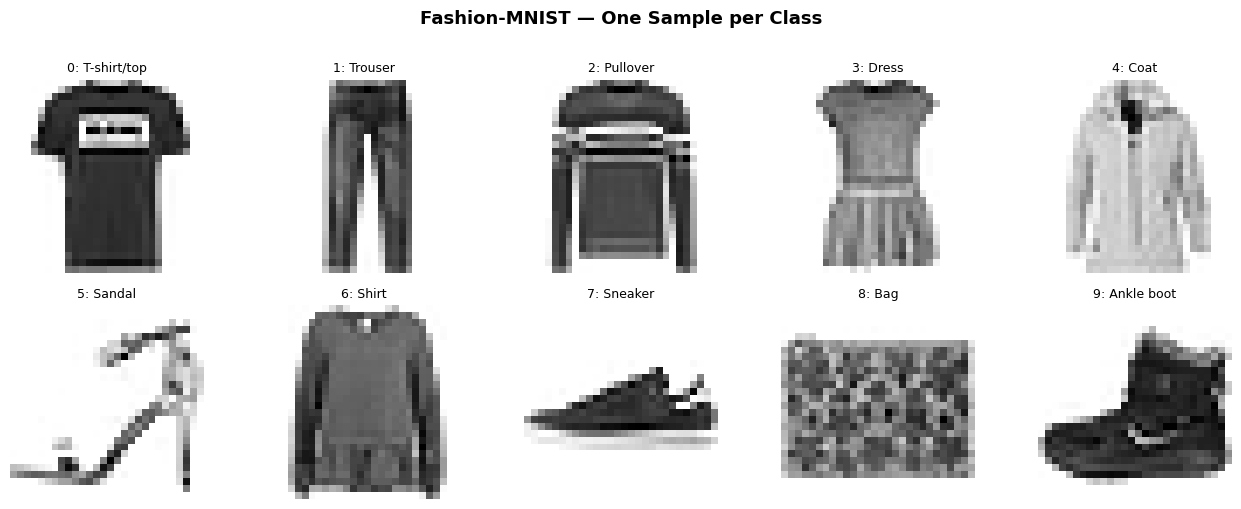

Figure saved: fig_01_sample_images.png


In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(13, 5))

for cls_id, ax in enumerate(axes.ravel()):
    # Pick first occurrence of each class
    idx = np.where(y_train_raw == cls_id)[0][0]
    ax.imshow(X_train_raw[idx], cmap='gray_r')
    ax.set_title(f'{cls_id}: {CLASS_NAMES[cls_id]}', fontsize=9)
    ax.axis('off')

plt.suptitle('Fashion-MNIST — One Sample per Class', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_01_sample_images.png', bbox_inches='tight', dpi=120)
plt.show()
print('Figure saved: fig_01_sample_images.png')

---
## 3. Preprocess & Create DataLoaders

Steps:
1. **Flatten** each 28×28 image to a 784-dimensional vector.
2. **Normalise** pixel values from [0, 255] → [0.0, 1.0] (divide by 255).
3. Convert to **PyTorch Tensors**.
4. Wrap in `TensorDataset` → `DataLoader`.

In [ ]:
BATCH_SIZE = 64

# ── Flatten: (N, 28, 28) → (N, 784) and normalise to [0, 1]
X_train = X_train_raw.reshape(-1, 784).astype(np.float32) / 255.0
X_test  = X_test_raw.reshape(-1, 784).astype(np.float32)  / 255.0

# ── Convert to PyTorch tensors
X_train_t = torch.tensor(X_train)
y_train_t = torch.tensor(y_train_raw, dtype=torch.long)
X_test_t  = torch.tensor(X_test)
y_test_t  = torch.tensor(y_test_raw,  dtype=torch.long)

# ── Create DataLoaders
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                          batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_t,  y_test_t),
                          batch_size=BATCH_SIZE, shuffle=False)

print(f'Train set   : {X_train.shape}  |  {len(train_loader)} batches of {BATCH_SIZE}')
print(f'Test  set   : {X_test.shape}   |  {len(test_loader)} batches of {BATCH_SIZE}')
print(f'Pixel range : [{X_train.min():.1f}, {X_train.max():.1f}]  (normalised)')

Train set   : (60000, 784)  |  938 batches of 64
Test  set   : (10000, 784)   |  157 batches of 64
Pixel range : [0.0, 1.0]  (normalised)


---
## 4. Define the ImageMLP

Architecture:

```
Input (784) → Linear(512) → BatchNorm → ReLU → Dropout(0.4)
            → Linear(256) → BatchNorm → ReLU → Dropout(0.3)
            → Linear(128) → ReLU
            → Linear(10)   ← raw logits (no Softmax — CrossEntropyLoss applies it internally)
```

- **BatchNorm** stabilises training by normalising activations within each batch.
- **Dropout** reduces overfitting.
- **No Sigmoid/Softmax on output** — `nn.CrossEntropyLoss` expects raw logits and applies `log_softmax` internally.

In [ ]:
class ImageMLP(nn.Module):
    """
    MLP for 10-class image classification on Fashion-MNIST.
    Input : 784 (flattened 28x28 grayscale image)
    Output: 10 raw logits (one per clothing class)
    """
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            # Hidden layer 1
            nn.Linear(784, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),
            # Hidden layer 2
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            # Hidden layer 3
            nn.Linear(256, 128),
            nn.ReLU(),
            # Output — 10 logits
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.network(x)


model = ImageMLP().to(DEVICE)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'\nTotal trainable parameters: {total_params:,}')

ImageMLP(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): ReLU()
    (10): Linear(in_features=128, out_features=10, bias=True)
  )
)

Total trainable parameters: 568,970


---
## 5. Train the Model

- **Loss:** `nn.CrossEntropyLoss` — combines `LogSoftmax` + negative log-likelihood; the standard choice for multi-class classification.
- **Optimizer:** Adam (lr = 0.001).
- **Epochs:** 10 (as required by the task).
- **LR Scheduler:** `StepLR` reduces the learning rate by ×0.5 every 4 epochs for finer convergence in later epochs.

In [ ]:
EPOCHS = 10
LR     = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=4, gamma=0.5)

train_losses, train_accs, test_accs = [], [], []

for epoch in range(1, EPOCHS + 1):
    # ── Training phase
    model.train()
    running_loss, correct_train = 0.0, 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        running_loss  += loss.item() * X_batch.size(0)
        correct_train += (logits.argmax(dim=1) == y_batch).sum().item()

    scheduler.step()

    epoch_loss     = running_loss  / len(train_loader.dataset)
    epoch_train_acc = correct_train / len(train_loader.dataset)

    # ── Evaluation phase
    model.eval()
    correct_test = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            logits = model(X_batch)
            correct_test += (logits.argmax(dim=1) == y_batch).sum().item()
    epoch_test_acc = correct_test / len(test_loader.dataset)

    train_losses.append(epoch_loss)
    train_accs.append(epoch_train_acc)
    test_accs.append(epoch_test_acc)

    print(f'Epoch {epoch:>2}/{EPOCHS} | '
          f'Loss: {epoch_loss:.4f} | '
          f'Train Acc: {epoch_train_acc*100:.2f}% | '
          f'Test Acc: {epoch_test_acc*100:.2f}%')

print(f'\nFinal Test Accuracy : {test_accs[-1]*100:.2f}%')

Epoch  1/10 | Loss: 0.5167 | Train Acc: 81.40% | Test Acc: 83.92%
Epoch  2/10 | Loss: 0.4028 | Train Acc: 85.19% | Test Acc: 84.93%
Epoch  3/10 | Loss: 0.3684 | Train Acc: 86.49% | Test Acc: 86.37%
Epoch  4/10 | Loss: 0.3451 | Train Acc: 87.34% | Test Acc: 86.87%
Epoch  5/10 | Loss: 0.3072 | Train Acc: 88.66% | Test Acc: 88.16%
Epoch  6/10 | Loss: 0.2921 | Train Acc: 89.03% | Test Acc: 88.52%
Epoch  7/10 | Loss: 0.2837 | Train Acc: 89.43% | Test Acc: 88.62%
Epoch  8/10 | Loss: 0.2777 | Train Acc: 89.66% | Test Acc: 89.03%
Epoch  9/10 | Loss: 0.2543 | Train Acc: 90.44% | Test Acc: 89.08%
Epoch 10/10 | Loss: 0.2478 | Train Acc: 90.76% | Test Acc: 89.31%

Final Test Accuracy : 89.31%


---
## 6. Evaluate the Model

Compute the final accuracy on all 10,000 test images and print a per-class breakdown.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        logits  = model(X_batch)
        probs   = torch.softmax(logits, dim=1)
        preds   = logits.argmax(dim=1)
        all_preds.append(preds.cpu())
        all_labels.append(y_batch)
        all_probs.append(probs.cpu())

all_preds  = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()
all_probs  = torch.cat(all_probs).numpy()

final_acc = (all_preds == all_labels).mean()
print(f'{'='*55}')
print(f'  FINAL TEST ACCURACY : {final_acc:.4f}  ({final_acc*100:.2f}%)')
print(f'  Evaluated on        : {len(all_labels):,} test images')
print(f'{'='*55}')
print()
print('Per-Class Report:')
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

  FINAL TEST ACCURACY : 0.8931  (89.31%)
  Evaluated on        : 10,000 test images

Per-Class Report:
              precision    recall  f1-score   support

 T-shirt/top       0.86      0.82      0.84      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.82      0.81      0.81      1000
       Dress       0.89      0.89      0.89      1000
        Coat       0.80      0.86      0.83      1000
      Sandal       0.97      0.96      0.96      1000
       Shirt       0.73      0.72      0.72      1000
     Sneaker       0.94      0.97      0.95      1000
         Bag       0.97      0.98      0.97      1000
  Ankle boot       0.97      0.95      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



---
## 7. Visualisations

### 7.1 Training Curves & Confusion Matrix

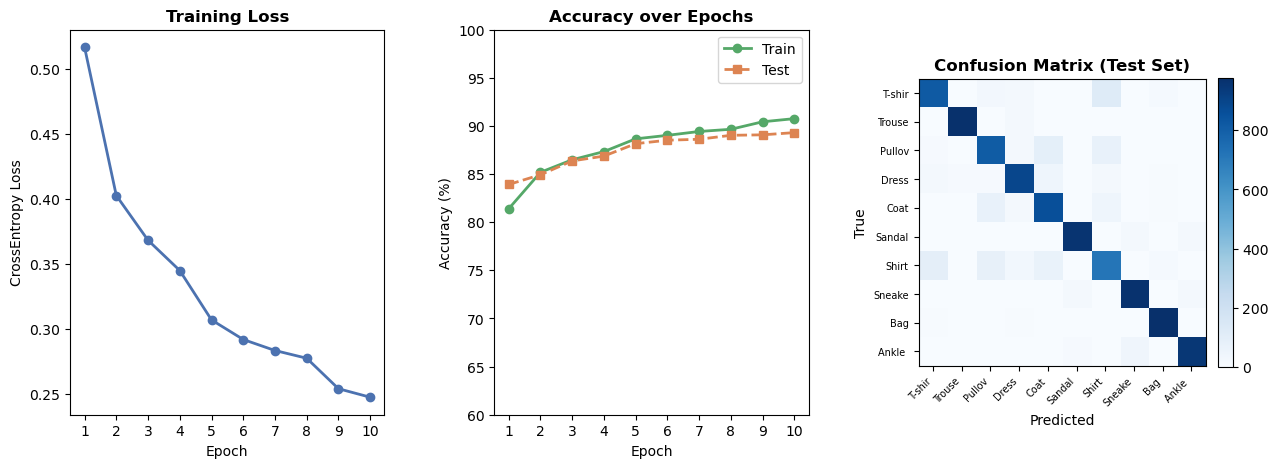

Figure saved: fig_02_training_curves.png


In [ ]:
fig = plt.figure(figsize=(15, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

epochs_range = range(1, EPOCHS + 1)

# ── Loss curve
ax0 = fig.add_subplot(gs[0])
ax0.plot(epochs_range, train_losses, 'o-', color='#4C72B0', lw=2)
ax0.set_title('Training Loss', fontweight='bold')
ax0.set_xlabel('Epoch')
ax0.set_ylabel('CrossEntropy Loss')
ax0.set_xticks(epochs_range)

# ── Accuracy curves
ax1 = fig.add_subplot(gs[1])
ax1.plot(epochs_range, [a*100 for a in train_accs], 'o-',
         color='#55A868', lw=2, label='Train')
ax1.plot(epochs_range, [a*100 for a in test_accs],  's--',
         color='#DD8452', lw=2, label='Test')
ax1.set_title('Accuracy over Epochs', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy (%)')
ax1.set_xticks(epochs_range)
ax1.legend()
ax1.set_ylim(60, 100)

# ── Confusion matrix
ax2 = fig.add_subplot(gs[2])
cm   = confusion_matrix(all_labels, all_preds)
im   = ax2.imshow(cm, cmap='Blues')
ax2.set_xticks(range(10))
ax2.set_yticks(range(10))
ax2.set_xticklabels([c[:6] for c in CLASS_NAMES], rotation=45, ha='right', fontsize=7)
ax2.set_yticklabels([c[:6] for c in CLASS_NAMES], fontsize=7)
ax2.set_title('Confusion Matrix (Test Set)', fontweight='bold')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('True')
plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)

plt.savefig('fig_02_training_curves.png', bbox_inches='tight', dpi=120)
plt.show()
print('Figure saved: fig_02_training_curves.png')

### 7.2 Correct Predictions

Ten randomly selected images the model classified correctly, with the predicted label and confidence.

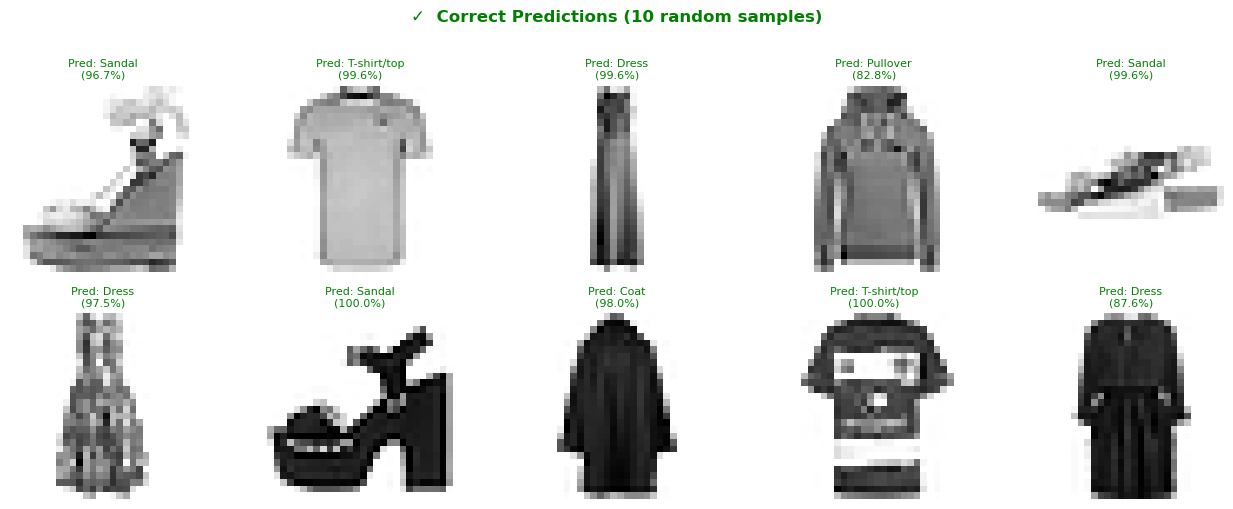

Figure saved: fig_03_correct_predictions.png


In [ ]:
rng = np.random.default_rng(SEED)

correct_mask = (all_preds == all_labels)
correct_idx  = np.where(correct_mask)[0]
chosen       = rng.choice(correct_idx, size=10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(13, 5))
for ax, idx in zip(axes.ravel(), chosen):
    img  = X_test[idx].reshape(28, 28)
    conf = all_probs[idx, all_preds[idx]] * 100
    ax.imshow(img, cmap='gray_r')
    ax.set_title(f'Pred: {CLASS_NAMES[all_preds[idx]]}\n({conf:.1f}%)',
                 color='green', fontsize=8)
    ax.axis('off')

plt.suptitle('✓  Correct Predictions (10 random samples)', fontsize=12,
             fontweight='bold', color='green', y=1.01)
plt.tight_layout()
plt.savefig('fig_03_correct_predictions.png', bbox_inches='tight', dpi=120)
plt.show()
print('Figure saved: fig_03_correct_predictions.png')

### 7.3 Incorrect Predictions

Ten randomly selected images the model got wrong. Each shows the **true label** vs. the **predicted label** — these misclassifications often reveal visually similar classes (e.g. Shirt ↔ T-shirt, Coat ↔ Pullover).

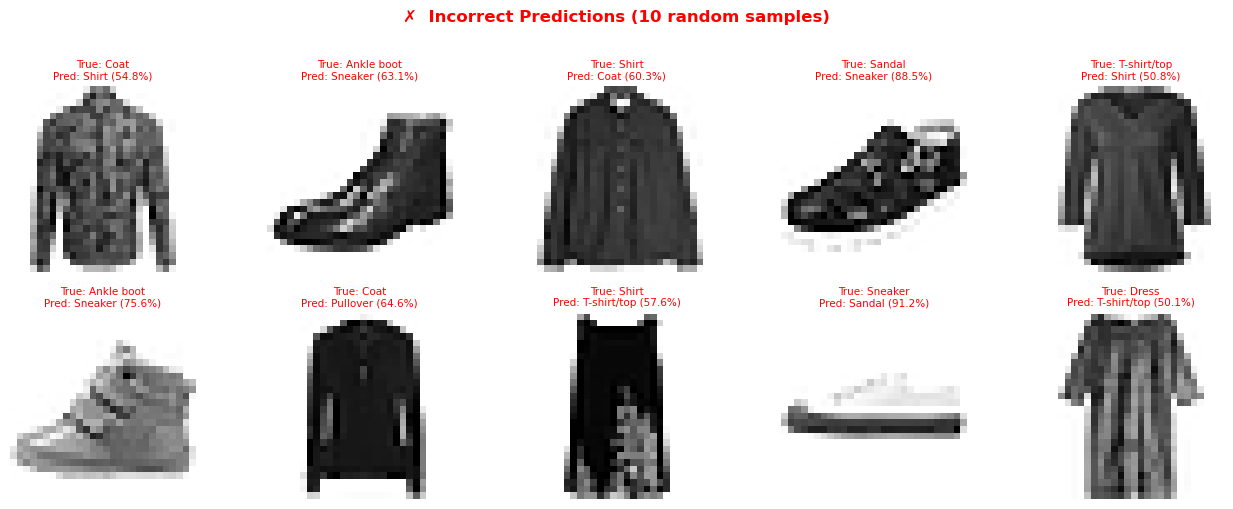

Figure saved: fig_04_incorrect_predictions.png


In [ ]:
wrong_mask = ~correct_mask
wrong_idx  = np.where(wrong_mask)[0]
chosen_w   = rng.choice(wrong_idx, size=10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(13, 5))
for ax, idx in zip(axes.ravel(), chosen_w):
    img  = X_test[idx].reshape(28, 28)
    conf = all_probs[idx, all_preds[idx]] * 100
    true_lbl = CLASS_NAMES[all_labels[idx]]
    pred_lbl = CLASS_NAMES[all_preds[idx]]
    ax.imshow(img, cmap='gray_r')
    ax.set_title(f'True: {true_lbl}\nPred: {pred_lbl} ({conf:.1f}%)',
                 color='red', fontsize=7.5)
    ax.axis('off')

plt.suptitle('✗  Incorrect Predictions (10 random samples)', fontsize=12,
             fontweight='bold', color='red', y=1.01)
plt.tight_layout()
plt.savefig('fig_04_incorrect_predictions.png', bbox_inches='tight', dpi=120)
plt.show()
print('Figure saved: fig_04_incorrect_predictions.png')

### 7.4 Per-Class Accuracy Bar Chart

Highlights which clothing categories the model finds easiest and hardest.

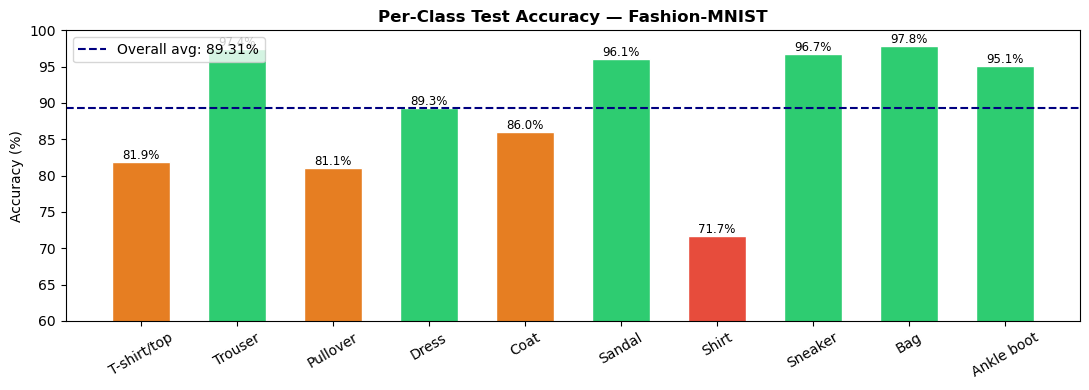

Figure saved: fig_05_per_class_accuracy.png


In [ ]:
per_class_acc = [
    (all_preds[all_labels == c] == c).mean() * 100
    for c in range(10)
]

colors = ['#2ecc71' if a >= 88 else '#e67e22' if a >= 78 else '#e74c3c'
          for a in per_class_acc]

fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.bar(CLASS_NAMES, per_class_acc, color=colors, edgecolor='white', width=0.6)
ax.axhline(final_acc * 100, color='navy', lw=1.5, linestyle='--',
           label=f'Overall avg: {final_acc*100:.2f}%')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Per-Class Test Accuracy — Fashion-MNIST', fontweight='bold')
ax.set_ylim(60, 100)
ax.tick_params(axis='x', rotation=30)
ax.legend()
for bar, val in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.4,
            f'{val:.1f}%', ha='center', fontsize=8.5)

plt.tight_layout()
plt.savefig('fig_05_per_class_accuracy.png', bbox_inches='tight', dpi=120)
plt.show()
print('Figure saved: fig_05_per_class_accuracy.png')

---
## 8. Summary

In [ ]:
best_class = CLASS_NAMES[np.argmax(per_class_acc)]
worst_class = CLASS_NAMES[np.argmin(per_class_acc)]

print(f"""
╔══════════════════════════════════════════════════════════════════╗
║          TASK 4 — RESULTS SUMMARY                              ║
╠══════════════════════════════════════════════════════════════════╣
║  Dataset    : Fashion-MNIST                                     ║
║  Train set  : 60,000 images  |  Test set: 10,000 images         ║
║  Classes    : 10 clothing categories                            ║
║  Input      : 784 (28×28 flattened, normalised [0,1])           ║
╠══════════════════════════════════════════════════════════════════╣
║  Model      : ImageMLP                                          ║
║               784 → 512 (BN+ReLU+Drop) → 256 (BN+ReLU+Drop)   ║
║               → 128 (ReLU) → 10 (logits)                       ║
║  Loss       : nn.CrossEntropyLoss                               ║
║  Optimizer  : Adam (lr=0.001, StepLR ×0.5 every 4 epochs)      ║
║  Epochs     : 10                                                ║
╠══════════════════════════════════════════════════════════════════╣
║  PERFORMANCE ON 10,000 TEST IMAGES                              ║
╠══════════════════════════════════════════════════════════════════╣""")
print(f'║  Final Test Accuracy : {final_acc:.4f}  ({final_acc*100:.2f}%)                  ║')
print(f'║  Best class          : {best_class:<20} ({max(per_class_acc):.1f}%)       ║')
print(f'║  Hardest class       : {worst_class:<20} ({min(per_class_acc):.1f}%)       ║')
print(f"""
╠══════════════════════════════════════════════════════════════════╣
║  KEY OBSERVATIONS                                               ║
║  • Trousers & bags are easiest (distinct shapes)                ║
║  • Shirts & T-shirts/Pullovers/Coats are hardest               ║
║    (similar silhouettes, model confuses these)                  ║
║  • A CNN would significantly outperform an MLP here             ║
║    by exploiting spatial structure in the images                ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║          TASK 4 — RESULTS SUMMARY                              ║
╠══════════════════════════════════════════════════════════════════╣
║  Dataset    : Fashion-MNIST                                     ║
║  Train set  : 60,000 images  |  Test set: 10,000 images         ║
║  Classes    : 10 clothing categories                            ║
║  Input      : 784 (28×28 flattened, normalised [0,1])           ║
╠══════════════════════════════════════════════════════════════════╣
║  Model      : ImageMLP                                          ║
║               784 → 512 (BN+ReLU+Drop) → 256 (BN+ReLU+Drop)   ║
║               → 128 (ReLU) → 10 (logits)                       ║
║  Loss       : nn.CrossEntropyLoss                               ║
║  Optimizer  : Adam (lr=0.001, StepLR ×0.5 every 4 epochs)      ║
║  Epochs     : 10                                                ║
╠════════════════════════════════════════════════